In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.svm import SVC

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [2]:
try:
    df = pd.read_csv('/content/data.csv')
    print('Dataset loaded from /content/data.csv')

except FileNotFoundError:
    cancer = load_breast_cancer(as_frame=True)
    df = cancer.frame.copy()

    df['diagnosis'] = df['target'].map({
        0: 'malignant',
        1: 'benign'
    })

    df.drop(columns=['target'], inplace=True)

    print('Built-in sklearn Breast Cancer dataset loaded as fallback')

df.head()

Built-in sklearn Breast Cancer dataset loaded as fallback


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,diagnosis
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,malignant
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,malignant
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,malignant
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,malignant
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,malignant


In [3]:
print('Shape of dataset:', df.shape)

print('\nColumn names:')
print(df.columns.tolist())

print('\nDataset information:')
df.info()

print('\nStatistical summary:')
print(df.describe(include='all'))

print('\nMissing values:')
print(df.isnull().sum())

Shape of dataset: (569, 31)

Column names:
['mean radius', 'mean texture', 'mean perimeter', 'mean area', 'mean smoothness', 'mean compactness', 'mean concavity', 'mean concave points', 'mean symmetry', 'mean fractal dimension', 'radius error', 'texture error', 'perimeter error', 'area error', 'smoothness error', 'compactness error', 'concavity error', 'concave points error', 'symmetry error', 'fractal dimension error', 'worst radius', 'worst texture', 'worst perimeter', 'worst area', 'worst smoothness', 'worst compactness', 'worst concavity', 'worst concave points', 'worst symmetry', 'worst fractal dimension', 'diagnosis']

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter      

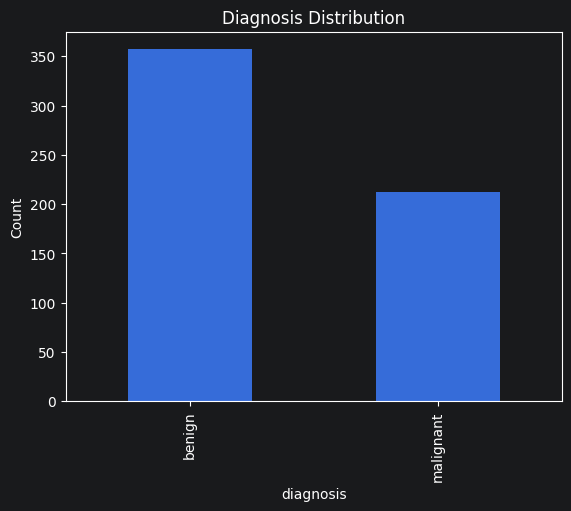

In [4]:
df['diagnosis'].value_counts().sort_index().plot(kind='bar')

plt.title('Diagnosis Distribution')
plt.xlabel('diagnosis')
plt.ylabel('Count')

plt.show()

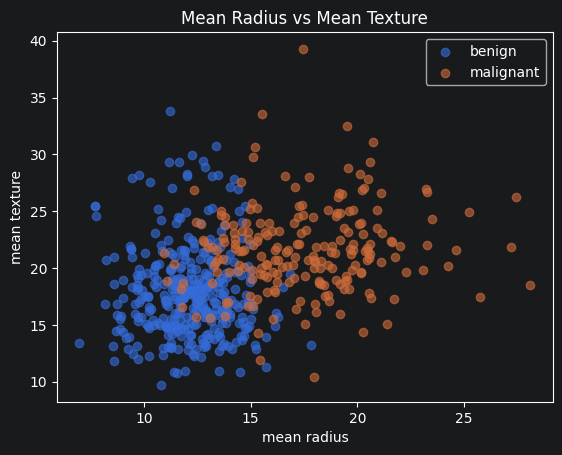

In [5]:
for cls, grp in df.groupby('diagnosis'):
    plt.scatter(grp['mean radius'], grp['mean texture'], label=cls, alpha=0.6)

plt.title('Mean Radius vs Mean Texture')
plt.xlabel('mean radius')
plt.ylabel('mean texture')

plt.legend()

plt.show()

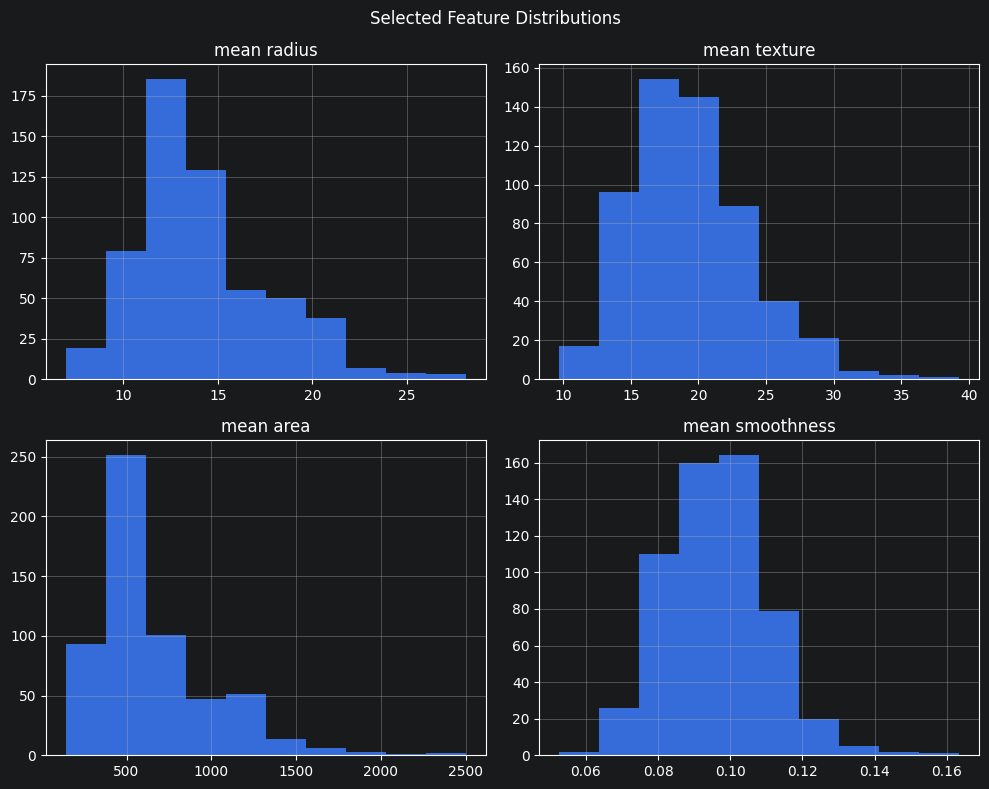

In [6]:
df[['mean radius', 'mean texture', 'mean area', 'mean smoothness']].hist(figsize=(10, 8))

plt.suptitle('Selected Feature Distributions')
plt.tight_layout()

plt.show()

In [7]:
if 'id' in df.columns:
    df.drop(columns=['id'], inplace=True)

if 'Unnamed: 32' in df.columns:
    df.drop(columns=['Unnamed: 32'], inplace=True)

selected_features = [
    'mean radius',
    'mean texture',
    'mean perimeter',
    'mean area',
    'mean smoothness',
    'mean compactness',
    'mean concavity',
    'mean concave points'
]

X = df[selected_features]
y = df['diagnosis']

imputer = SimpleImputer(strategy='median')

X = imputer.fit_transform(X)

In [8]:
label_encoder = LabelEncoder()

y_encoded = label_encoder.fit_transform(y)

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print('Encoded classes:')
for idx, label in enumerate(label_encoder.classes_):
    print(f'{idx} -> {label}')

Encoded classes:
0 -> benign
1 -> malignant


In [9]:
print('Selected Features:')
for feature in selected_features:
    print('-', feature)

Selected Features:
- mean radius
- mean texture
- mean perimeter
- mean area
- mean smoothness
- mean compactness
- mean concavity
- mean concave points


In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

In [11]:
model = SVC(kernel='rbf', C=2, gamma='scale')

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [12]:
accuracy = accuracy_score(y_test, y_pred)

cm = confusion_matrix(y_test, y_pred)

report = classification_report(
    y_test,
    y_pred,
    target_names=label_encoder.classes_
)

print('Accuracy:', accuracy)

print('\nConfusion Matrix:\n', cm)

print('\nClassification Report:\n', report)

Accuracy: 0.9736842105263158

Confusion Matrix:
 [[71  1]
 [ 2 40]]

Classification Report:
               precision    recall  f1-score   support

      benign       0.97      0.99      0.98        72
   malignant       0.98      0.95      0.96        42

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



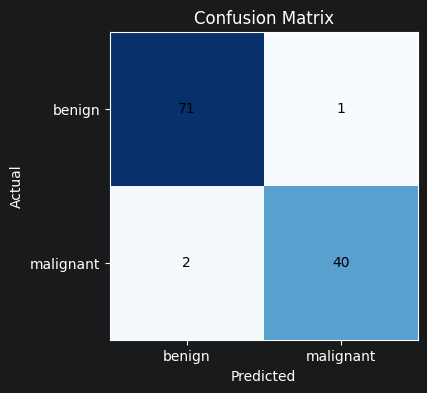

In [14]:
plt.figure(figsize=(6, 4))

plt.imshow(cm, cmap='Blues')

# Add numbers inside each cell
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j],
                 ha='center', va='center',
                 color='black')

plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.xticks(range(len(label_encoder.classes_)), label_encoder.classes_)
plt.yticks(range(len(label_encoder.classes_)), label_encoder.classes_)

plt.show()